In [1]:
# ============================================
# ROUTE PLANNING AGENT FOR INDIAN CITIES
# Using BFS, DFS and UCS
# ============================================

import heapq
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

# Indian cities and road distances (in km)
graph = {
    "Hyderabad": {
        "Bengaluru": 570,
        "Chennai": 630,
        "Nagpur": 500
    },

    "Bengaluru": {
        "Hyderabad": 570,
        "Chennai": 350,
        "Mumbai": 980
    },

    "Chennai": {
        "Hyderabad": 630,
        "Bengaluru": 350,
        "Mumbai": 1330,
        "Kolkata": 1660
    },

    "Nagpur": {
        "Hyderabad": 500,
        "Mumbai": 820,
        "Bhopal": 350,
        "Delhi": 1080
    },

    "Bhopal": {
        "Nagpur": 350,
        "Jaipur": 600,
        "Delhi": 900
    },

    "Mumbai": {
        "Bengaluru": 980,
        "Chennai": 1330,
        "Nagpur": 820,
        "Ahmedabad": 530,
        "Jaipur": 1140
    },

    "Ahmedabad": {
        "Mumbai": 530,
        "Jaipur": 670,
        "Delhi": 950
    },

    "Jaipur": {
        "Bhopal": 600,
        "Mumbai": 1140,
        "Ahmedabad": 670,
        "Delhi": 280
    },

    "Delhi": {
        "Nagpur": 1080,
        "Bhopal": 900,
        "Ahmedabad": 950,
        "Jaipur": 280
    },

    "Kolkata": {
        "Chennai": 1660
    }
}

# Starting and destination cities
start = "Hyderabad"
goal = "Delhi"

print("Indian City Route Planning Problem")
print("----------------------------------")
print("Start City :", start)
print("Goal City  :", goal)
print("Number of Cities :", len(graph))

Indian City Route Planning Problem
----------------------------------
Start City : Hyderabad
Goal City  : Delhi
Number of Cities : 10


In [2]:
# ============================================
# BFS - BREADTH FIRST SEARCH
# ============================================

def bfs(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        city = path[-1]

        if city == goal:
            return path

        if city not in visited:
            visited.add(city)

            for neighbor in graph[city]:
                if neighbor not in visited:
                    new_path = path + [neighbor]
                    queue.append(new_path)

    return None


# Run BFS
bfs_path = bfs(graph, start, goal)

print("BFS Route Planning")
print("------------------")
print("Start :", start)
print("Goal  :", goal)
print("BFS Path :", " -> ".join(bfs_path))
print("Number of Steps :", len(bfs_path) - 1)

BFS Route Planning
------------------
Start : Hyderabad
Goal  : Delhi
BFS Path : Hyderabad -> Nagpur -> Delhi
Number of Steps : 2


In [3]:
# ============================================
# DFS - DEPTH FIRST SEARCH
# ============================================

def dfs(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        city = path[-1]

        if city == goal:
            return path

        if city not in visited:
            visited.add(city)

            # Add neighbours to stack
            for neighbor in reversed(list(graph[city].keys())):
                if neighbor not in visited:
                    new_path = path + [neighbor]
                    stack.append(new_path)

    return None


# Run DFS
dfs_path = dfs(graph, start, goal)

print("DFS Route Planning")
print("------------------")
print("Start :", start)
print("Goal  :", goal)
print("DFS Path :", " -> ".join(dfs_path))
print("Number of Steps :", len(dfs_path) - 1)

DFS Route Planning
------------------
Start : Hyderabad
Goal  : Delhi
DFS Path : Hyderabad -> Bengaluru -> Chennai -> Mumbai -> Nagpur -> Bhopal -> Jaipur -> Ahmedabad -> Delhi
Number of Steps : 8


In [4]:
# ============================================
# UCS - UNIFORM COST SEARCH
# ============================================

def ucs(graph, start, goal):
    priority_queue = [(0, [start])]
    visited = set()

    while priority_queue:
        cost, path = heapq.heappop(priority_queue)
        city = path[-1]

        if city == goal:
            return path, cost

        if city in visited:
            continue

        visited.add(city)

        for neighbor, distance in graph[city].items():
            if neighbor not in visited:
                new_cost = cost + distance
                new_path = path + [neighbor]
                heapq.heappush(priority_queue, (new_cost, new_path))

    return None, float("inf")


# Run UCS
ucs_path, ucs_cost = ucs(graph, start, goal)

print("UCS Route Planning")
print("------------------")
print("Start :", start)
print("Goal  :", goal)
print("UCS Path :", " -> ".join(ucs_path))
print("Total Distance :", ucs_cost, "km")

UCS Route Planning
------------------
Start : Hyderabad
Goal  : Delhi
UCS Path : Hyderabad -> Nagpur -> Delhi
Total Distance : 1580 km


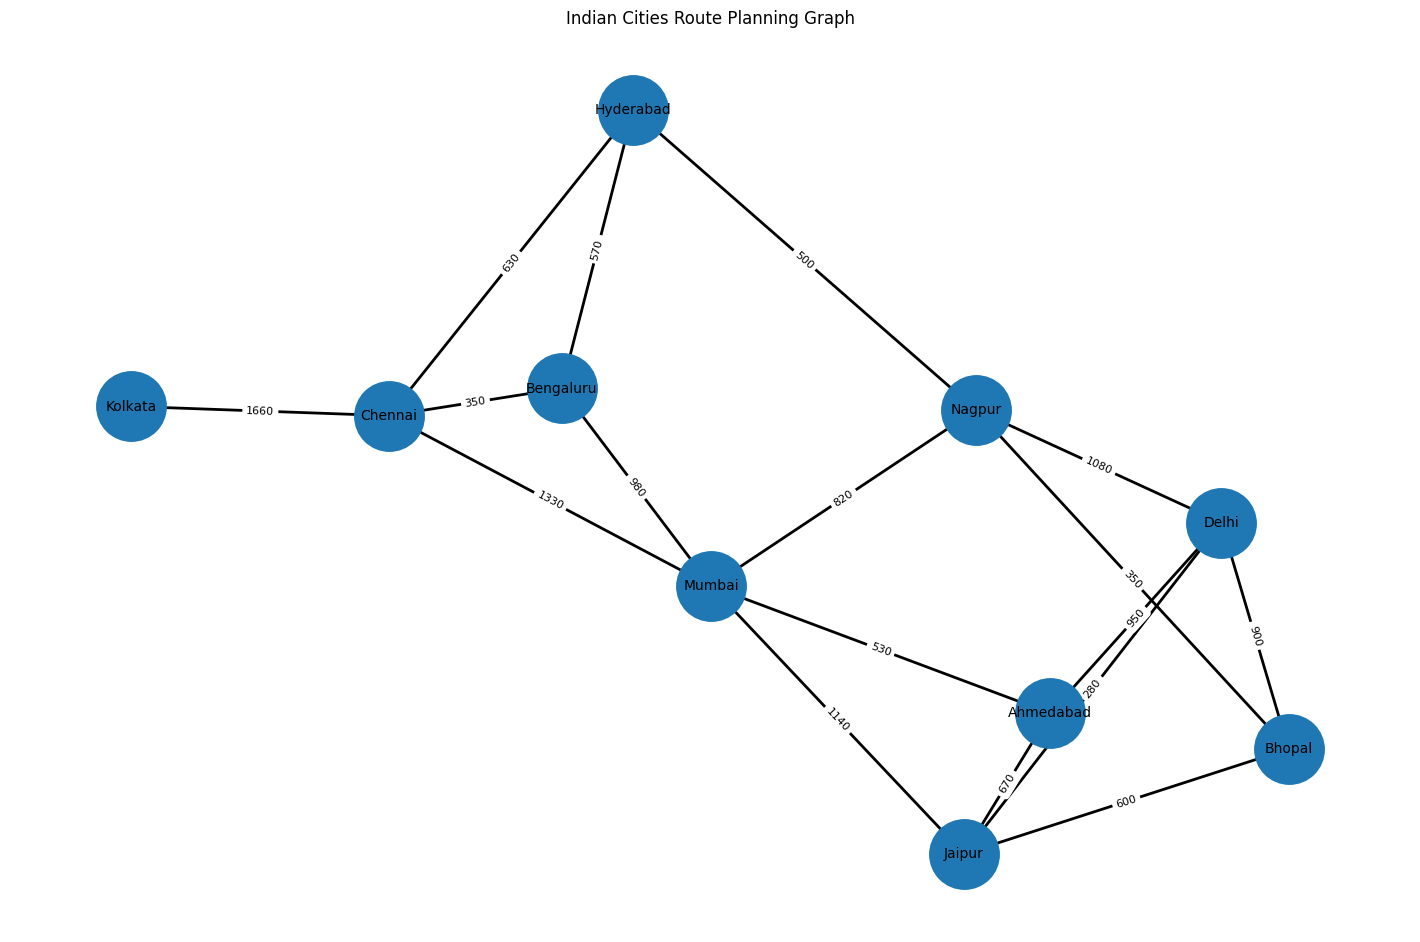

In [5]:
# ============================================
# INDIAN CITY ROAD GRAPH VISUALIZATION
# ============================================

G = nx.Graph()

# Add roads and distances
for city in graph:
    for neighbor, distance in graph[city].items():
        G.add_edge(city, neighbor, weight=distance)

plt.figure(figsize=(14, 9))

# Create positions
pos = nx.spring_layout(G, seed=42)

# Draw cities and roads
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    width=2
)

# Show road distances
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Indian Cities Route Planning Graph")
plt.show()

Observation

The BFS, DFS and UCS search algorithms were implemented for route planning between Indian cities. BFS found a route based on the number of steps, while DFS explored the graph deeply before reaching the destination. UCS considered the distance of each road and selected the route with the minimum total cost. For the given graph, UCS found the route Hyderabad → Nagpur → Delhi with a total distance of 1580 km.

Result

The Route Planning Agent for Indian Cities was successfully implemented using BFS, DFS and UCS. The experiment demonstrated how different search algorithms find routes in a connected city graph. BFS and DFS searched based on the structure of the graph, while UCS used road distances to determine the minimum-cost route.